# MVP Análise de Dados e Boas Práticas

**Aluna:** Ana Nery Alves Daniel

**Matrícula:** 4052024002341

**Dataset:** [Microdados da Educação Superior 2023](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-da-educacao-superior) e [Municípios do Ceará segundo Regiões de Planejamento](https://www.ipece.ce.gov.br/regioes-de-planejamento/)


# Descrição do Problema

Concentração de sedes administrativas de instituições de ensino superior (IES) do Ceará somente em poucas regiões do estado, bem como baixo número de docentes em exercício declarados pretos nessas instituições em relação ao número total.


# Objetivo

Realizar levantamento de quais municípios do estado do Ceará têm baixo quantitativo ou ausência de sedes administrativa de instituições de ensino superior (IES), identificando esse número por região de planejanto do CE (1), bem como detectar o número de docentes declarados pretos nessas sedes a fim de justificar a expansão de políticas afirmativas para esse grupo e melhorar a distribuição de IES no referido estado.

Ao final do levantamento, será sugerida a ampliação de sede de instituições de ensino superior no CE por Região de Planejamento do estado.

# Recorte

O foco deste levantamento são as instituiçõe-sede administrativas de ensino do estado do Ceará, e não inclui unidades menores dessas instituições (polos) em razão desses dados não terem sido disponibilizados pelo Inep. Portanto, considera-se IES neste levantamento somente as sedes administrativas dessas instituições.

<br>
(1) Região de Planejamento do estado do Ceará: Divisões territoriais criadas para organizar o planejamento e a implementação de políticas públicas. Classificação do Instituto de Pesquisa e Estratégia Econômica do Ceará - IPECE.

## Hipóteses do Problema


*   Má distribuição de iInstituições de ensino superior no estado do Ceará, havendo alta concentração na região de planejamento Grande Fortaleza em detrimento das demais regiões do estado.

* Baixo número de docentes declarados pretos nas instituições de ensino superior do Ceará em relação ao quantitativo total desses professores.


## Tipo de Problema

O problema explorado neste dataset pode ser classificado, a priori, como não supervisionado, uma vez que não foram identificadas em levantamento inicial as características necessárias para definir um padrão de comportamento para agrupar os dados. Contudo, ressalta-se que esta pesquisa irá focar somente no entendimento e mineração dos dados, realizando sua exploração, análise estatística e transformação de variáveis ("feature engineering") se necessário.

##COLETA DE DADOS

## Seleção de Dados

O dataset deste trabalho é composto por duas fontes de dados. A primeira fonte lista um conjunto de sedes de instituições de ensino superior no Brasil, obtidas do [Censo Inep de 2023](https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/censo-da-educacao-superior), e a segunda fonte lista os municípios do estado do Ceará por região de planejamento administrativo, sendo esse obtido do [Ipece](https://www.ipece.ce.gov.br/regioes-de-planejamento/).

Optou-se por filtrar e analisar somente os dados do estado do Ceará em razão da facilidade de acesso à lista de regiões de planejamento desse estado, o que não ocorreu com as demais regiões do país. Vale ressaltar que o Ipece fornece a lista de municípios classificada por região de planejamento, mas não fornece nenhum dos critérios utilizados para essa classificação.

In [110]:
import pandas as pd

# Carregar o dataset
url_ies = 'https://raw.githubusercontent.com/neryana/pos-ciencia-dados/refs/heads/main/Sprint-AnaliseDadosEBoasPraticas/datasets/MICRODADOS_ED_SUP_IES_2023.CSV%20-%20BRUTOS.csv'
df_ies = pd.read_csv(url_ies)

# Filtrar os registros onde SG_UF_IES é igual a 'CE'
df_ce = df_ies[df_ies['SG_UF_IES'] == 'CE']

# Contar a quantidade de valores únicos na coluna SG_IES
quantidade_unique_SG_IES = df_ce['SG_IES'].nunique()

print(f'A quantidade de SG_IES não repetidos na UF CE é: {quantidade_unique_SG_IES}')

A quantidade de SG_IES não repetidos na UF CE é: 75


In [111]:
import pandas as pd

# Carregar o dataset a partir da URL
url_regioes = "https://raw.githubusercontent.com/neryana/pos-ciencia-dados/refs/heads/main/Sprint-AnaliseDadosEBoasPraticas/datasets/Lista_Regioes_Planejamento_Ceara.csv"
df_regioes = pd.read_csv(url_regioes)

# Remover espaços em branco nas colunas, se houver
df_regioes.columns = df_regioes.columns.str.strip()

# Verificar se existe alguma coluna com nome parecido com 'Regiao'
print(df_regioes.columns)

# Agora, contar o número de regiões distintas
if 'Regiao' in df_regioes.columns:
    num_regioes = df_regioes['Regiao'].nunique()
    print(f'\nO número de regiões distintas é: {num_regioes}')
else:
    print("\nA coluna 'Regiao' não foi encontrada no DataFrame.")

Index(['Código do município (IBGE)', 'Nome do município', 'Regiao'], dtype='object')

O número de regiões distintas é: 14


In [112]:
# Contar o número de municípios únicos na coluna 'Nome do município'
num_municipios = df_regioes['Nome do município'].nunique()

print(f'O número de municípios é: {num_municipios}')

O número de municípios é: 184


## Atributos do Dataset

**Dataset Instituições de Ensino Superior (IES)**

Este dataset contém 75 sedes de instituições de ensino superior no Ceará conforme consulta acima. Os atributos dessas instituições utilizados nesta pesquisa estão descritos abaixo:

| Nome da coluna | Tipo | Tamanho | Descrição |
| -------- | ----- | ----- | ----------- |
| CO_IES | Num | 8 | Código único de identificação da IES |
| NO_MUNICIPIO_IES | Char | 150 | Nome do Município da sede administrativa ou reitoria da IES
| NO_IES | Char | 200 | Nome da IES
| SG_IES |Char | 20 | Sigla da IES
| SG_UF_IES |Char | 2 | Sigla da Unidade da Federação da sede administrativa ou reitoria da IES
| CO_MUNICIPIO_IES | Num | 7 | Código do município da sede administrativa da IES
| TIPO_REDE | Char | 7 | Tipo de rede de ensino (1. pública /2.privada)
| QT_DOC_EXE | Num | 8 | Quantidade total de docentes em exercício
| QT_DOC_EX_PRETA | Num | 8 | Quantidade de docentes em exercício - Cor/Raça preta

<br>

**Dataset Regiões de Planejamento do Ceará**

Este dataset contém 184 municípios divididos em 14 Regiões de Planejamento. Os atributos dessas instituições utilizados nesta pesquisa estão descritos abaixo:

| Nome da coluna | Tipo | Tamanho | Descrição |
| -------- | ----- | ----- | ----------- |
| CO_MUNICIPIO | Num| 7 | Código do município da sede administrativa da IES |
| Nome do município | Char | 150 | Nome do Município da sede administrativa ou reitoria da IES
| Região de Planejamento | Char | 100 | Nome da região de planejamento do Ceará.



# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados.

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [114]:
# carregamento do dataset instituições de ensino superior (ies)
url_ies = 'https://raw.githubusercontent.com/neryana/pos-ciencia-dados/refs/heads/main/modelagem%20vers%C3%A3o%203/MICRODADOS_ED_SUP_IES_2023.CSV%20-%20BRUTOS.csv'


In [115]:
# primeiras linhas do dataframe ies
df_ies.head()

,NU_ANO_CENSO,NO_REGIAO_IES,CO_REGIAO_IES,NO_UF_IES,SG_UF_IES,CO_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,IN_CAPITAL_IES,NO_MESORREGIAO_IES,CO_MESORREGIAO_IES,NO_MICRORREGIAO_IES,CO_MICRORREGIAO_IES,TP_ORGANIZACAO_ACADEMICA,TP_REDE,TP_CATEGORIA_ADMINISTRATIVA,IN_COMUNITARIA,IN_CONFESSIONAL,NO_MANTENEDORA,CO_MANTENEDORA,CO_IES,NO_IES,SG_IES,DS_ENDERECO_IES,DS_NUMERO_ENDERECO_IES,DS_COMPLEMENTO_ENDERECO_IES,NO_BAIRRO_IES,NU_CEP_IES,QT_TEC_TOTAL,QT_TEC_FUNDAMENTAL_INCOMP_FEM,QT_TEC_FUNDAMENTAL_INCOMP_MASC,QT_TEC_FUNDAMENTAL_COMP_FEM,QT_TEC_FUNDAMENTAL_COMP_MASC,QT_TEC_MEDIO_FEM,QT_TEC_MEDIO_MASC,QT_TEC_SUPERIOR_FEM,QT_TEC_SUPERIOR_MASC,QT_TEC_ESPECIALIZACAO_FEM,QT_TEC_ESPECIALIZACAO_MASC,QT_TEC_MESTRADO_FEM,QT_TEC_MESTRADO_MASC,QT_TEC_DOUTORADO_FEM,QT_TEC_DOUTORADO_MASC,IN_ACESSO_PORTAL_CAPES,IN_ACESSO_OUTRAS_BASES,IN_ASSINA_OUTRA_BASE,IN_REPOSITORIO_INSTITUCIONAL,IN_BUSCA_INTEGRADA,IN_SERVICO_INTERNET,IN_PARTICIPA_REDE_SOCIAL,IN_CATALOGO_ONLINE,QT_PERIODICO_ELETRONICO,QT_LIVRO_ELETRONICO,QT_DOC_TOTAL,QT_DOC_EXE,QT_DOC_EX_FEMI,QT_DOC_EX_MASC,QT_DOC_EX_SEM_GRAD,QT_DOC_EX_GRAD,QT_DOC_EX_ESP,QT_DOC_EX_MEST,QT_DOC_EX_DOUT,QT_DOC_EX_INT,QT_DOC_EX_INT_DE,QT_DOC_EX_INT_SEM_DE,QT_DOC_EX_PARC,QT_DOC_EX_HOR,QT_DOC_EX_0_29,QT_DOC_EX_30_34,QT_DOC_EX_35_39,QT_DOC_EX_40_44,QT_DOC_EX_45_49,QT_DOC_EX_50_54,QT_DOC_EX_55_59,QT_DOC_EX_60_MAIS,QT_DOC_EX_BRANCA,QT_DOC_EX_PRETA,QT_DOC_EX_PARDA,QT_DOC_EX_AMARELA,QT_DOC_EX_INDIGENA,QT_DOC_EX_COR_ND,QT_DOC_EX_BRA,QT_DOC_EX_EST,QT_DOC_EX_COM_DEFICIENCIA
0,2023,Centro-Oeste,5,Mato Grosso,MT,51,Cuiabá,5103403,1,Centro-Sul Mato-grossense,4,Cuiabá,17,1,1,1,0,0,FUNDACAO UNIVERSIDADE FEDERAL DE MATO GROSSO,1,1,UNIVERSIDADE FEDERAL DE MATO GROSSO,UFMT,Avenida Fernando Correa da Costa,2367,Cidade Universitária,Boa Esperança,78060900.0,1335,2,15,1,11,27,59,87,106,331,327,172,107,55,35,1,0,1,1,1,1,1,1,50,50,1742,1588,764,824,0,83,51,191,1263,1537,1276,261,51,0,44,144,298,318,276,197,136,175,1003,85,454,38,6,2,1559,29,12
1,2023,Centro-Oeste,5,Distrito Federal,DF,53,Brasília,5300108,1,Distrito Federal,1,Brasília,1,1,1,1,0,0,FUNDACAO UNIVERSIDADE DE BRASILIA,2,2,UNIVERSIDADE DE BRASÍLIA,UNB,Campus Universitário Darcy Ribeiro,s/n,-,Asa Norte,70910900.0,2906,0,0,2,24,100,118,177,225,746,704,386,265,93,66,1,0,1,1,1,1,1,1,441,13095,3120,2801,1288,1513,0,9,18,224,2550,2647,2323,324,154,0,44,146,335,500,482,369,377,548,1958,109,625,66,11,32,2669,132,10
2,2023,Nordeste,2,Sergipe,SE,28,São Cristóvão,2806701,0,Leste Sergipano,3,Aracaju,11,1,1,1,0,0,FUNDACAO UNIVERSIDADE FEDERAL DE SERGIPE,3,3,UNIVERSIDADE FEDERAL DE SERGIPE,UFS,Avenida Marechal Rondon,s/n,-,Jardim Rosa Elze,49100000.0,1769,0,23,8,12,211,137,269,188,275,187,219,137,65,38,1,0,1,1,1,1,1,1,40939,320055,1820,1768,846,922,0,100,2,210,1456,1652,1441,211,115,1,36,127,258,359,331,250,202,205,242,36,295,11,1,1183,1739,29,5
3,2023,Norte,1,Amazonas,AM,13,Manaus,1302603,1,Centro Amazonense,3,Manaus,7,1,1,1,0,0,FUNDACAO UNIVERSIDADE DO AMAZONAS,4,4,UNIVERSIDADE FEDERAL DO AMAZONAS,UFAM,Av. Rodrigo Otávio,6200,Unidade Sede,Coroado II,69077000.0,1931,9,54,5,40,116,201,225,258,389,266,169,134,35,30,1,0,1,1,0,1,1,1,41,6272,2051,2048,934,1114,0,94,200,537,1217,1868,1466,402,180,0,112,217,328,344,295,248,249,255,167,22,1684,6,2,167,2048,0,6
4,2023,Nordeste,2,Piauí,PI,22,Teresina,2211001,1,Centro-Norte Piauiense,2,Teresina,3,1,1,1,0,0,FUNDACAO UNIVERSIDADE FEDERAL DO PIAUI,14054,5,UNIVERSIDADE FEDERAL DO PIAUÍ,UFPI,Campus Universitário Ministro Petrônio Portela,s/n,SG - 07,Ininga,64049550.0,2243,128,223,58,82,340,508,51,71,258,211,135,99,44,35,1,0,1,1,1,1,1,1,0,0,1693,1469,710,759,2,5,70,250,1142,1374,1174,200,95,0,22,134,231,304,228,144,163,243,164,41,257,3,1,1003,1469,0,0


In [116]:
# carregamento do dataset das regiões de planejamento do Ceará
url_regioes = 'https://raw.githubusercontent.com/neryana/pos-ciencia-dados/refs/heads/main/modelagem%20vers%C3%A3o%203/Lista_Regioes_Planejamento_Ceara.csv'


In [117]:
# primeiras linhas do dataframe regiões de planejamento
df_regioes.head()

,Código do município (IBGE),Nome do município,Regiao
0,2300101,Abaiara,Cariri
1,2300150,Acarape,Maciço de Baturité
2,2300200,Acaraú,Litoral Norte
3,2300309,Acopiara,Centro Sul
4,2300408,Aiuaba,Sertão dos Inhamuns


# ANÁLISE DE DADOS

Esta etapa traz uma visão geral dos dados obtidos dos dois datasets que irão compor a análise deste trabalho (Instituições de Ensino Superior e Regiões de Planejamento do Ceará) a partir dos quais será realizada filtragem dos dados, bem como outros tratamentos necessários para obter as informações indispensáveis para atingir o objetivo desta pesquisa.

## Total e Tipo das Instâncias

**Dataset Instituições de Ensino Superior**

Este dataset possui 2580 instâncias (observações) nas quais existem variáveis do tipo categórica, como as que definem o nome do município, estado e das sedes das instituições de ensino superior (IES); e numérica do tipo inteiro, como as que quantificam o total de docentes, de docentes por cor, bem como a variável ano.

**Dataset Regiões de Planejamento do Ceará**

Este dataset possui 184 instâncias (observações) somente com variáveis categóricas: nome do município, nome da região e código do município.




In [118]:
# Obter o tipo de cada coluna Instituições de Ensino Superior
tipos = df_ies.dtypes

# Obter o total de instâncias (linhas) Instituições de Ensino Superior
total_instancias = len(df_ies)

print("Tipos de cada coluna:\n", tipos)
print("\nTotal de instâncias (linhas):", total_instancias)

Tipos de cada coluna:
 NU_ANO_CENSO                  int64
NO_REGIAO_IES                object
CO_REGIAO_IES                 int64
NO_UF_IES                    object
SG_UF_IES                    object
                              ...  
QT_DOC_EX_INDIGENA            int64
QT_DOC_EX_COR_ND              int64
QT_DOC_EX_BRA                 int64
QT_DOC_EX_EST                 int64
QT_DOC_EX_COM_DEFICIENCIA     int64
Length: 84, dtype: object

Total de instâncias (linhas): 2580


In [119]:
# Obter o tipo de cada coluna Regiões de Planejamento do Ceará
tipos = df_regioes.dtypes

# Obter o total de instâncias (linhas) Regiões de Planejamento do Ceará
total_instancias = len(df_regioes)

print("Tipos de cada coluna:\n", tipos)
print("\nTotal de instâncias (linhas):", total_instancias)

Tipos de cada coluna:
 Código do município (IBGE)     int64
Nome do município             object
Regiao                        object
dtype: object

Total de instâncias (linhas): 184


## Delimitando o dataset para Instituições de Ensino Superior (IES) somente do estado do Ceará

Na seção a seguir será realizada a filtragem do dataset das Instituições de Ensino Superior (IES) para retornar somente as instituições do estado do Ceará, substituindo os código 1 e 2 da coluna TP Rede pelo seu significado, pública e privada, respectivamente.

In [120]:
# 1. Lista de colunas desejadas
colunas = [
    'CO_IES',
    'NO_IES',
    'SG_IES',
    'SG_UF_IES',
    'NO_MUNICIPIO_IES',
    'CO_MUNICIPIO_IES',
    'TP_REDE',
    'QT_DOC_EXE',
    'QT_DOC_EX_PRETA'
]

df = df_ies[colunas]

# 2. Filtrar linhas onde SG_UF_IES == 'CE'
df_ce = df[df['SG_UF_IES'] == 'CE'].copy()

# 3. Substituir valores da coluna TP_REDE para textos descritivos
df_ce['TP_REDE'] = df_ce['TP_REDE'].map({1: 'pública', 2: 'privada'})

# (Removido o filtro que mantinha apenas instituições públicas)

# 4. Organizar display como tabela
df_ce.reset_index(drop=True, inplace=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_ce.head()

,CO_IES,NO_IES,SG_IES,SG_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,TP_REDE,QT_DOC_EXE,QT_DOC_EX_PRETA
0,29,UNIVERSIDADE ESTADUAL DO CEARÁ,UECE,CE,Fortaleza,2304400,pública,1138,16
1,95,UNIVERSIDADE ESTADUAL VALE DO ACARAÚ,UVA,CE,Sobral,2312908,pública,508,33
2,555,UNIVERSIDADE DE FORTALEZA,UNIFOR,CE,Fortaleza,2304400,privada,960,13
3,583,UNIVERSIDADE FEDERAL DO CEARÁ,UFC,CE,Fortaleza,2304400,pública,2332,76
4,746,UNIVERSIDADE REGIONAL DO CARIRI,URCA,CE,Crato,2304202,pública,552,10


## Identificando se há **valores ausentes** no dataset Instituições de Ensino Superior no Ceará (df_ce)


In [121]:
# Verificar colunas com valores ausentes em df_ce
colunas_com_ausentes = df_ce.columns[df_ce.isnull().any()]

# Exibir colunas com valores ausentes e a quantidade de valores faltantes
print("Colunas com valores ausentes em df_ce:")
print(df_ce[colunas_com_ausentes].isnull().sum())

Colunas com valores ausentes em df_ce:
SG_IES    22
dtype: int64


**Análise**: A consulta acima identificou 22 valores ausentes na coluna SG_IES. Possivelmente, ou essas IES não têm sigla, ou simplesmente esse valor não foi informado. Assim, como tratamento, o dataframe irá substituir os valores ausentes por "Não informada", a partir do comando a seguir:

In [122]:
# Substituir os NaNs da coluna SG_IES por "Não informada"
df_ce['SG_IES'] = df_ce['SG_IES'].fillna('Não informada')

# Exibir as 20 primeiras linhas do DataFrame
df_ce.head(10)

,CO_IES,NO_IES,SG_IES,SG_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,TP_REDE,QT_DOC_EXE,QT_DOC_EX_PRETA
0,29,UNIVERSIDADE ESTADUAL DO CEARÁ,UECE,CE,Fortaleza,2304400,pública,1138,16
1,95,UNIVERSIDADE ESTADUAL VALE DO ACARAÚ,UVA,CE,Sobral,2312908,pública,508,33
2,555,UNIVERSIDADE DE FORTALEZA,UNIFOR,CE,Fortaleza,2304400,privada,960,13
3,583,UNIVERSIDADE FEDERAL DO CEARÁ,UFC,CE,Fortaleza,2304400,pública,2332,76
4,746,UNIVERSIDADE REGIONAL DO CARIRI,URCA,CE,Crato,2304202,pública,552,10
5,1059,Faculdade Multiversa de Fortaleza,Não informada,CE,Fortaleza,2304400,privada,14,0
6,1107,Centro Universitário Estácio do Ceará,Estácio Ceará,CE,Fortaleza,2304400,privada,564,12
7,1191,INSTITUTO DE ENSINO SUPERIOR DE FORTALEZA,IESF,CE,Fortaleza,2304400,privada,12,0
8,1350,Centro Universitário Multiversa do Jaguaribe- ...,UNIJAGUARIBE,CE,Aracati,2301109,privada,90,3
9,1425,Faculdade Evoluir,FAEV,CE,Fortaleza,2304400,privada,20,0


## Identificando se há **valores ausentes** no dataset Regiões de Planejamento do Ceará (df_regioes)

In [123]:
# Verificar colunas com valores ausentes em df_ce
colunas_com_ausentes = df_regioes.columns[df_regioes.isnull().any()]

# Exibir colunas com valores ausentes e a quantidade de valores faltantes
print("Colunas com valores ausentes em df_regioes:")
print(df_regioes[colunas_com_ausentes].isnull().sum())

Colunas com valores ausentes em df_regioes:
Series([], dtype: float64)


**Análise:** Conforme a consulta acima, **não** foram identificados valores ausentes no dataset Regiões de Planejamento.

## Identificando se há **valores inconsistentes ou outliers** no dataset Instituições de Ensino Superior no Ceará (df_ce)

In [124]:
# Função que detecta outliers e explica a faixa central (Q1 a Q3)
def detectar_outliers_iqr(df, coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Criar nova coluna booleana com True para outlier
    nome_coluna_outlier = f"{coluna}_outlier"
    df[nome_coluna_outlier] = ~df[coluna].between(limite_inferior, limite_superior, inclusive='both')

    # Mensagem explicativa
    print(f"\nColuna: {coluna}")
    print(f"  - Q1 (1º quartil): {Q1:.2f}")
    print(f"  - Q3 (3º quartil): {Q3:.2f}")
    print(f"  - Intervalo Interquartil (IQR): {IQR:.2f}")
    print(f"  - Faixa central esperada (sem outliers): de {limite_inferior:.2f} até {limite_superior:.2f}")

    total_outliers = df[nome_coluna_outlier].sum()
    if total_outliers > 0:
        print(f"  - Outliers detectados: {total_outliers} valor(es) fora da faixa")
    else:
        print("  - Nenhum outlier detectado.")

# Colunas a serem analisadas
colunas_para_analisar = ['QT_DOC_EXE', 'QT_DOC_EX_PRETA']

# Aplicar a função para cada coluna
for coluna in colunas_para_analisar:
    detectar_outliers_iqr(df_ce, coluna)

# Verificar valores negativos
for coluna in colunas_para_analisar:
    negativos = (df_ce[coluna] < 0).sum()
    if negativos > 0:
        print(f"\n Valores negativos detectados na coluna '{coluna}': {negativos}")
    else:
        print(f"\n Nenhum valor negativo detectado na coluna '{coluna}'.")

# Remover colunas _outlier não desejadas
colunas_validas = ['QT_DOC_EXE_outlier', 'QT_DOC_EX_PRETA_outlier']
colunas_a_remover = [col for col in df_ce.columns if col.endswith('_outlier') and col not in colunas_validas]
df_ce.drop(columns=colunas_a_remover, inplace=True)

# Exibir as 10 primeiras linhas
df_ce.head(10)



Coluna: QT_DOC_EXE
  - Q1 (1º quartil): 14.00
  - Q3 (3º quartil): 92.00
  - Intervalo Interquartil (IQR): 78.00
  - Faixa central esperada (sem outliers): de -103.00 até 209.00
  - Outliers detectados: 14 valor(es) fora da faixa

Coluna: QT_DOC_EX_PRETA
  - Q1 (1º quartil): 0.00
  - Q3 (3º quartil): 2.00
  - Intervalo Interquartil (IQR): 2.00
  - Faixa central esperada (sem outliers): de -3.00 até 5.00
  - Outliers detectados: 14 valor(es) fora da faixa

 Nenhum valor negativo detectado na coluna 'QT_DOC_EXE'.

 Nenhum valor negativo detectado na coluna 'QT_DOC_EX_PRETA'.


,CO_IES,NO_IES,SG_IES,SG_UF_IES,NO_MUNICIPIO_IES,CO_MUNICIPIO_IES,TP_REDE,QT_DOC_EXE,QT_DOC_EX_PRETA,QT_DOC_EXE_outlier,QT_DOC_EX_PRETA_outlier
0,29,UNIVERSIDADE ESTADUAL DO CEARÁ,UECE,CE,Fortaleza,2304400,pública,1138,16,True,True
1,95,UNIVERSIDADE ESTADUAL VALE DO ACARAÚ,UVA,CE,Sobral,2312908,pública,508,33,True,True
2,555,UNIVERSIDADE DE FORTALEZA,UNIFOR,CE,Fortaleza,2304400,privada,960,13,True,True
3,583,UNIVERSIDADE FEDERAL DO CEARÁ,UFC,CE,Fortaleza,2304400,pública,2332,76,True,True
4,746,UNIVERSIDADE REGIONAL DO CARIRI,URCA,CE,Crato,2304202,pública,552,10,True,True
5,1059,Faculdade Multiversa de Fortaleza,Não informada,CE,Fortaleza,2304400,privada,14,0,False,False
6,1107,Centro Universitário Estácio do Ceará,Estácio Ceará,CE,Fortaleza,2304400,privada,564,12,True,True
7,1191,INSTITUTO DE ENSINO SUPERIOR DE FORTALEZA,IESF,CE,Fortaleza,2304400,privada,12,0,False,False
8,1350,Centro Universitário Multiversa do Jaguaribe- ...,UNIJAGUARIBE,CE,Aracati,2301109,privada,90,3,False,False
9,1425,Faculdade Evoluir,FAEV,CE,Fortaleza,2304400,privada,20,0,False,False


**Análise:** Conforme consulta acima, para facilitar a identificação dos outliers, foram criadas duas colunas a mais onde, para cada linha do dataframe, os dados considerados outliers apresentam valor "true" e os que não são valor "false". Foi analisada a existência de outliers somente para as colunas QT_DOC_EX e QT_DOC_EX_PRETA, únicas que são numéricas. As demais são códigos.

O resultado apontou a existência de 14 outliers na quantidade total de docentes em exercício (QT_DOC_EXE) e 14 outliers na quantidade de docentes declarados pretos (QT_DOC_EX_PRETA).

Apesar de discrepantes, os outliers são valores reais e estão corretos, por isso, é importante exibi-los para evidenciar a discrepância na distribuição de docentes entre os municípios.

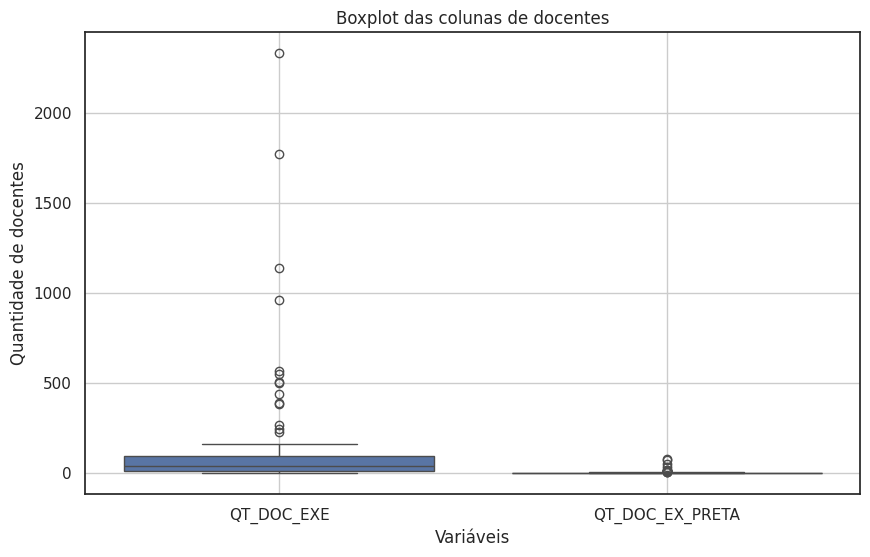

In [125]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ce[colunas_para_analisar])
plt.title("Boxplot das colunas de docentes")
plt.ylabel("Quantidade de docentes")
plt.xlabel("Variáveis")
plt.grid(True)
plt.show()


**Análise do gráfico gerado**

O gráfico Boxplot evidencia os outliers identificados na consulta anterior. Pela figura, é possível observarmos vários outliers bem acima da faixa central esperada exibida na consulta anterior, cujo válor máximo seria 209 para a quantidade de docentes em exercício (QT_DOC_EXE), sendo o maior deles valor superior a 2000.Já os outliers referentes à quantidade de docentes em exercício declarados pretos (QT_DOC_EX_PRETA) também rigistrou outliers, porém com valores mais próximos à faixa central, com máximo até 5.

###Novas Variáveis Geradas - Quantitativos por Município (df_ies_docentes_municipio_regiao)

A partir dos datasets df_ce (lista de instituições e docentes do Ceará) e df_regiao (lista de regiões de planejamento do Ceará), será feito abaixo um merge desses datasest, criando o dataset df_ies_docentes_municipio_regiao. Essa consulta é interessante para dar uma visão do número de IES e docentes total e na cor preta em cada município, indentificando, inclusive, os municípios com 0 instituição e 0 docente, se houver. Assim, serão geradas novas variáveis:


**QTD_IES_MUNICIPIO:** Quantidade de instituições de ensino superior no município.

**QTD_DOC_EXE_MUNICIPIO:** Quantidade de docentes em exercício das instituições de ensino superior no município.

**QTD_DOC_EXE_PRETA_MUNICIPIO:** Quantidade de docentes em exercício declarados pretos nas instituições de ensino superior no município.

In [126]:
# ================================
# Passo 1: Agrupar dados por município (df_ce)
# ================================
df_agrupado = df_ce.groupby('CO_MUNICIPIO_IES').agg(
    QTD_IES_MUNICIPIO=('NO_IES', 'nunique'),
    QTD_DOC_EXE_MUNICIPIO=('QT_DOC_EXE', 'sum'),
    QTD_DOC_EXE_PRETA_MUNICIPIO=('QT_DOC_EX_PRETA', 'sum')
).reset_index()

# ================================
# Passo 2: Preparar df_regiao (renomear colunas para facilitar merge)
# ================================
df_regioes_renomeado = df_regioes.rename(columns={
    'Código do município (IBGE)': 'CO_MUNICIPIO_IES',
    'Nome do município': 'NO_MUNICIPIO_IES'
})

# ================================
# Passo 3: Realizar o merge (left join para manter todos os municípios)
# ================================
df_ies_docentes_municipio_regiao = df_regioes_renomeado.merge(
    df_agrupado,
    on='CO_MUNICIPIO_IES',
    how='left'
)

# ================================
# Passo 4: Substituir NaN por 0 e converter para inteiro
# ================================
colunas_qtd = ['QTD_IES_MUNICIPIO', 'QTD_DOC_EXE_MUNICIPIO', 'QTD_DOC_EXE_PRETA_MUNICIPIO']

df_ies_docentes_municipio_regiao[colunas_qtd] = df_ies_docentes_municipio_regiao[colunas_qtd].fillna(0).astype(int)

# Passo 5: Mover a coluna 'Regiao' para o final
# ================================
colunas = [col for col in df_ies_docentes_municipio_regiao.columns if col != 'Regiao'] + ['Regiao']
df_ies_docentes_municipio_regiao = df_ies_docentes_municipio_regiao[colunas]

# ================================
# Exibir as 10 primeiras linhas
# ================================
df_ies_docentes_municipio_regiao.head(184)



,CO_MUNICIPIO_IES,NO_MUNICIPIO_IES,QTD_IES_MUNICIPIO,QTD_DOC_EXE_MUNICIPIO,QTD_DOC_EXE_PRETA_MUNICIPIO,Regiao
0,2300101,Abaiara,0,0,0,Cariri
1,2300150,Acarape,0,0,0,Maciço de Baturité
2,2300200,Acaraú,0,0,0,Litoral Norte
3,2300309,Acopiara,0,0,0,Centro Sul
4,2300408,Aiuaba,0,0,0,Sertão dos Inhamuns
...,...,...,...,...,...,...
179,2313807,Uruburetama,0,0,0,Litoral Oeste / Vale do Curu
180,2313906,Uruoca,0,0,0,Litoral Norte
181,2313955,Varjota,0,0,0,Sertão de Sobral
182,2314003,Várzea Alegre,0,0,0,Cariri


##Gráfico dos 20 Municípios com o Maior Número de Instituições de Ensino Superior

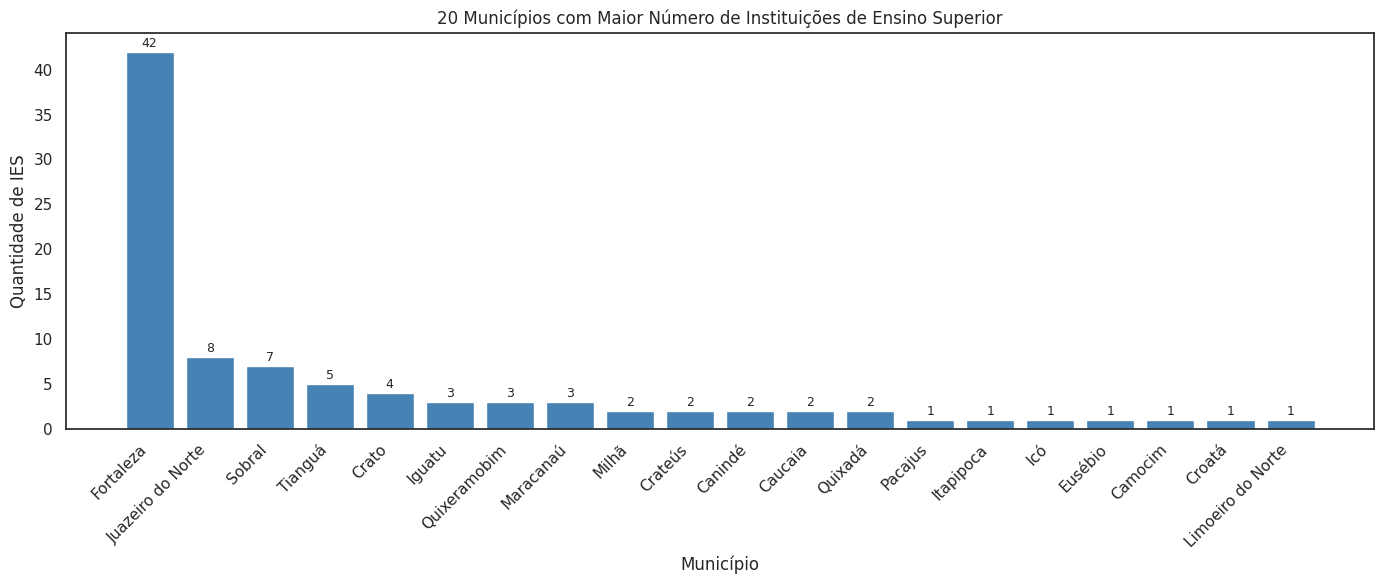

In [127]:
# Selecionar os 20 municípios com maior número de IES
df_top_20_ies = df_ies_docentes_municipio_regiao.sort_values(
    by='QTD_IES_MUNICIPIO', ascending=False
).head(20)

# Criar gráfico de barras verticais
plt.figure(figsize=(14, 6))
plt.bar(df_top_20_ies['NO_MUNICIPIO_IES'], df_top_20_ies['QTD_IES_MUNICIPIO'], color='steelblue')

# Personalizar gráfico
plt.xlabel('Município')
plt.ylabel('Quantidade de IES')
plt.title('20 Municípios com Maior Número de Instituições de Ensino Superior')
plt.xticks(rotation=45, ha='right')
plt.grid(False)  # Remover grid

# Exibir valores nas barras
for i, valor in enumerate(df_top_20_ies['QTD_IES_MUNICIPIO']):
    plt.text(i, valor + 0.2, str(valor), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()




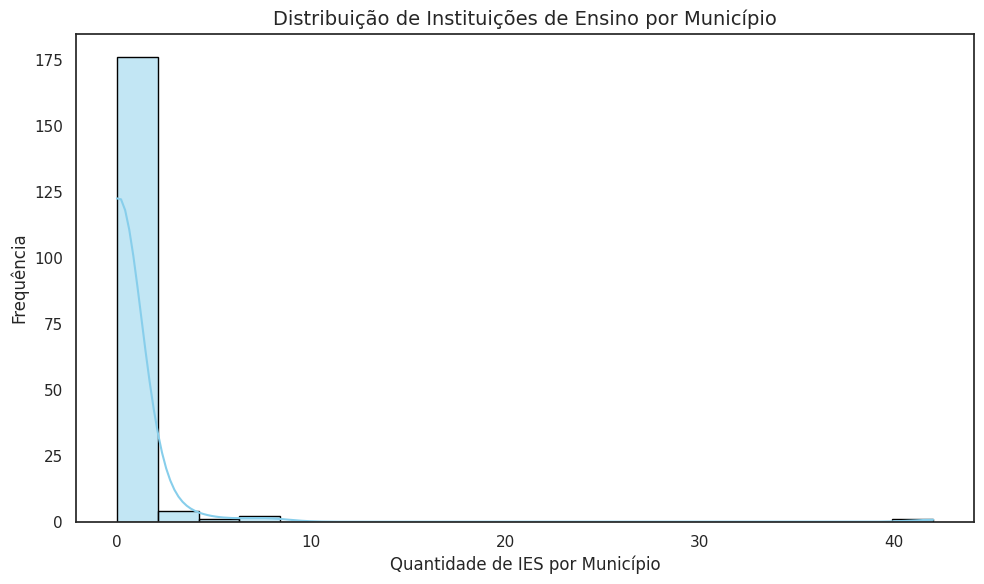

In [128]:
# Definir o estilo do gráfico (sem grid)
sns.set_style("white")

# Criar a figura
plt.figure(figsize=(10, 6))

# Plotar histograma com curva de densidade
sns.histplot(
    data=df_ies_docentes_municipio_regiao,
    x='QTD_IES_MUNICIPIO',
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='black'
)

# Personalizar o gráfico
plt.title('Distribuição de Instituições de Ensino por Município', fontsize=14)
plt.xlabel('Quantidade de IES por Município', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(False)  # Remover grid

plt.tight_layout()
plt.show()


**Análise do Gráfico:** O histograma acima, distorcido à direita, evidencia a ocorrência de altos valores com baixa frequência, ou seja, enquanto a maioria dos municípios têm até 5 instituições de ensino superior, apenas 1 tem mais de 40.

## Novas Variáveis Geradas - Quantitativos por Região (**Dataset Final**: *df_resultado_regiao*)

Como dito anteriormente, esta pesquisa tem como base dois datasets. Um que traz o quantitativo de instituições de ensino e de docentes por município e outro dataset que traz os municípios do Ceará por região de planejamento. Como o alvo da pesquisa é mapear a quantidade de IES e de docentes (total e declarados pretos) por região de planejamento, a partir do dataset gerado anterioremente, o qual fez o merge entre os datasets de origem e foi nomeado de df_ies_docentes_municipio_regiao, será feito agora um agrupamento criando novas variáveis, agora não mais agrupadas por municípios, mas, sim, agrupadas por região, que é foco final do trabalho. Assim, serão cridas as variáveis abaixo: QTD_IES_REGIAO, QTD_DOC_EXE_REGIAO e QTD_DOC_EXE_PRETA_REGIAO.

In [129]:
# Agrupar por região e calcular as métricas
df_resultado_regiao = (
    df_ies_docentes_municipio_regiao.groupby('Regiao')
    .agg(
        QTD_IES_REGIAO=('QTD_IES_MUNICIPIO', 'sum'),
        QTD_DOC_EXE_REGIAO=('QTD_DOC_EXE_MUNICIPIO', 'sum'),
        QTD_DOC_EXE_PRETA_REGIAO=('QTD_DOC_EXE_PRETA_MUNICIPIO', 'sum')
    )
    .reset_index()
)

# Exibir resultado
print(df_resultado_regiao)

                          Regiao  QTD_IES_REGIAO  QTD_DOC_EXE_REGIAO  QTD_DOC_EXE_PRETA_REGIAO
0                         Cariri              12                1634                        55
1                     Centro Sul               4                 231                        10
2               Grande Fortaleza              52                9539                       216
3                  Litoral Leste               1                  90                         3
4                  Litoral Norte               1                  14                         1
5   Litoral Oeste / Vale do Curu               1                   0                         0
6             Maciço de Baturité               2                 491                        73
7              Serra da Ibiapaba               7                 351                        10
8                 Sertão Central               7                 263                         6
9              Sertão de Canindé               2  

## Identificando se há valores inconsistentes ou outliers no Dataframe Resultado (df_resultado_regiao)

In [130]:
# 1️ Selecionar apenas colunas numéricas para análise de outliers
colunas_numericas = df_resultado_regiao.select_dtypes(include='number')

# 2️ Calcular estatísticas descritivas: Q1 (25%), Q3 (75%) e IQR
Q1 = colunas_numericas.quantile(0.25)
Q3 = colunas_numericas.quantile(0.75)
IQR = Q3 - Q1

# 3️ Definir limites para detecção de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4️ Identificar valores fora dos limites (outliers)
mascara_outliers = (colunas_numericas < limite_inferior) | (colunas_numericas > limite_superior)

# 5️ Filtrar linhas com ao menos um outlier
df_outliers = df_resultado_regiao[mascara_outliers.any(axis=1)]

# 6️ Exibir regiões com valores atípicos
print("\n Regiões com valores potencialmente inconsistentes (outliers):")
print(df_outliers)

# 7️ Exibir estatísticas detalhadas
print("\n Estatísticas por coluna:")
for coluna in colunas_numericas.columns:
    print(f"\n Coluna: {coluna}")
    print(f"  Q1 (25%): {Q1[coluna]}")
    print(f"  Q3 (75%): {Q3[coluna]}")
    print(f"  IQR     : {IQR[coluna]}")
    print(f"  Limite inferior: {limite_inferior[coluna]}")
    print(f"  Limite superior: {limite_superior[coluna]}")



 Regiões com valores potencialmente inconsistentes (outliers):
              Regiao  QTD_IES_REGIAO  QTD_DOC_EXE_REGIAO  QTD_DOC_EXE_PRETA_REGIAO
0             Cariri              12                1634                        55
2   Grande Fortaleza              52                9539                       216
10  Sertão de Sobral               7                1202                        50

 Estatísticas por coluna:

 Coluna: QTD_IES_REGIAO
  Q1 (25%): 1.25
  Q3 (75%): 7.0
  IQR     : 5.75
  Limite inferior: -7.375
  Limite superior: 15.625

 Coluna: QTD_DOC_EXE_REGIAO
  Q1 (25%): 45.75
  Q3 (75%): 456.0
  IQR     : 410.25
  Limite inferior: -569.625
  Limite superior: 1071.375

 Coluna: QTD_DOC_EXE_PRETA_REGIAO
  Q1 (25%): 1.5
  Q3 (75%): 40.0
  IQR     : 38.5
  Limite inferior: -56.25
  Limite superior: 97.75


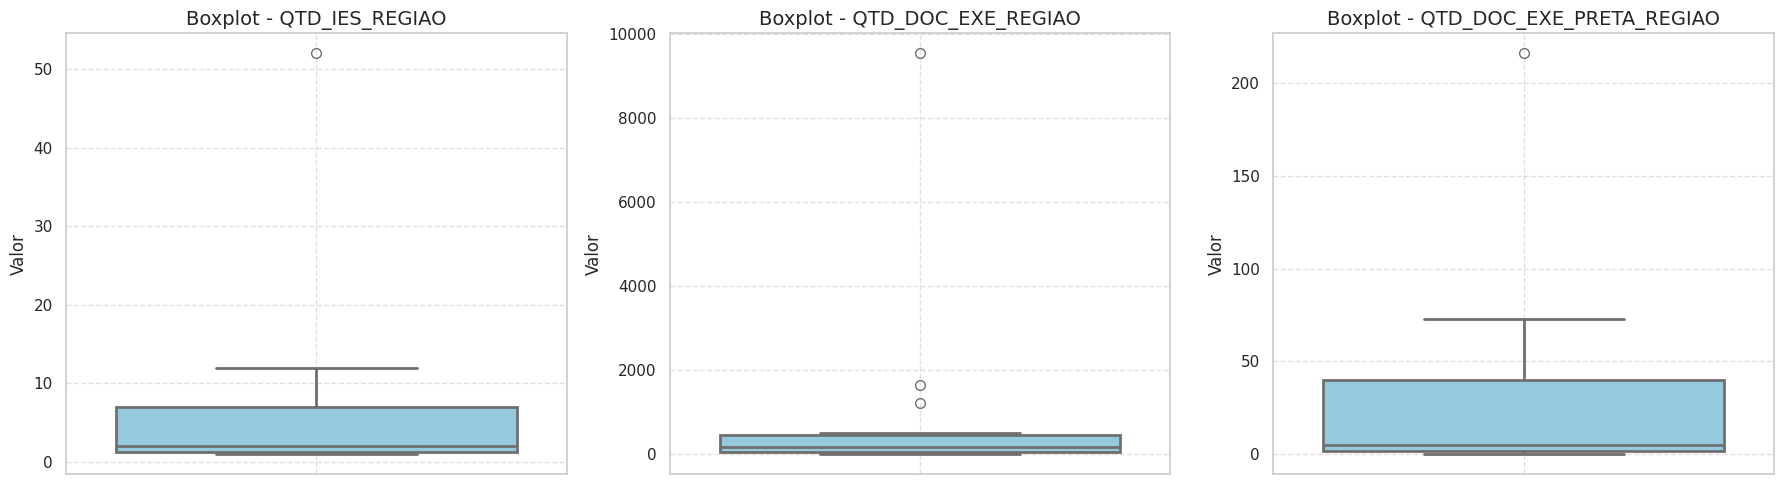

In [131]:
# Garante que os gráficos sejam exibidos com estilo mais agradável
sns.set(style="whitegrid")

# Lista de colunas numéricas que serão analisadas
colunas_numericas = ['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']

# Define o tamanho da figura geral
plt.figure(figsize=(18, 5))

# Loop para gerar 1 boxplot por variável
for i, coluna in enumerate(colunas_numericas):
    plt.subplot(1, 3, i + 1)  # Cria subplots lado a lado
    sns.boxplot(data=df_resultado_regiao, y=coluna, color="skyblue", fliersize=7, linewidth=2)
    plt.title(f"Boxplot - {coluna}", fontsize=14)
    plt.ylabel('Valor')
    plt.xlabel('')  # Remove o eixo x (opcional)
    plt.grid(True, linestyle='--', alpha=0.6)

# Ajusta layout para não sobrepor textos
plt.tight_layout()
plt.show()


**Análise dos Gráficos**

QTD_IES_REGIAO:

*   A maioria das regiões possui até 7 instituições de ensino superior (IES), com a mediana próxima de 2. Grande Fortaleza é um outlier claro, com 52 IES, muito acima das demais regiões.

QTD_DOC_EXE_REGIAO

* A distribuição mostra grande variação entre as regiões, com muitos valores
concentrados abaixo de 500. Grande Fortaleza novamente se destaca como outlier, com quase 10 mil docentes, superando muito o restante.

QTD_DOC_EXE_PRETA_REGIAO

* A maioria das regiões tem menos de 10 docentes autodeclarados pretos, indicando baixa representatividade. Maciço de Baturité e especialmente Grande Fortaleza aparecem como outliers, com 73 e 216 docentes pretos, respectivamente.



## Estatística Descritiva

A estatística abaixo tomará como base o dataframe resultado (df_resultado), com as variáveis geradas por região de planejamento, que é o foco da pesquisa.
<br>



In [132]:
# Estatística descritiva das colunas numéricas
print("\nEstatística descritiva das métricas por região:\n")
print(df_resultado_regiao.describe().round(2))



Estatística descritiva das métricas por região:

       QTD_IES_REGIAO  QTD_DOC_EXE_REGIAO  QTD_DOC_EXE_PRETA_REGIAO
count           14.00               14.00                     14.00
mean             7.21             1000.64                     30.93
std             13.31             2505.34                     58.44
min              1.00                0.00                      0.00
25%              1.25               45.75                      1.50
50%              2.00              160.50                      5.00
75%              7.00              456.00                     40.00
max             52.00             9539.00                    216.00



**Análise dos Dados Estatísticos**
<br>
<br>
- Quantidade de Instituições por Região (QTD_IES_REGIAO)

A distribuição das Instituições de Ensino Superior (IES) entre as regiões analisadas é bastante desigual. Enquanto a **média geral** é de pouco mais de 7 instituições por região, a maioria delas possui apenas 1 ou 2 IES, como mostra a **mediana**. Por outro lado, uma única região concentra 52 instituições, evidenciando uma concentração significativa em locais específicos. Essa diferença é confirmada pelo **desvio padrão** elevado (13.3), que indica uma grande variação entre as regiões. Isso mostra que o acesso ao ensino superior pode estar muito limitado em diversas partes do território. negrito

<br>

- Quantidade de Docentes em Exercício por Região (QT_DOC_EXE_REGIAO)

Da mesma forma, a quantidade de docentes em exercício por região também apresenta um padrão de concentração. Apesar da **média** ser de cerca de 1.000 docentes por região, a **mediana** revela que metade das regiões tem menos de 160 docentes. Em contrapartida, uma região concentra mais de 9.500 docentes. Além disso, algumas regiões não têm nenhum docente registrado. Isso reverbera em um **desvio padrão** bastante elevado (2505.34), indicando uma grande variação entre as regiões. Essa distribuição desigual sugere que a oferta de professores também está fortemente centralizada, o que pode impactar diretamente a qualidade e o alcance da educação superior.


<br>

- Quantidade de Docentes Declarados Pretos por Região (QT_DOC_EX_PRETA_REGIAO)

Quando analisamos a presença de docentes pretos por região, a desigualdade é ainda mais evidente. Enquanto a **média** é de 30 docentes pretos por região, metade das regiões têm apenas 5 ou menos, e algumas não possuem nenhum. A maior concentração está em uma única região com 216 docentes pretos. O alto **desvio padrão** reforça essa disparidade. Esses dados apontam para uma sub-representação racial significativa em grande parte do território, o que pode estar ligado a barreiras estruturais de acesso e permanência de profissionais pretos no ensino superior.


#Histogramas com Curva de Densidade da Estatística Descritiva

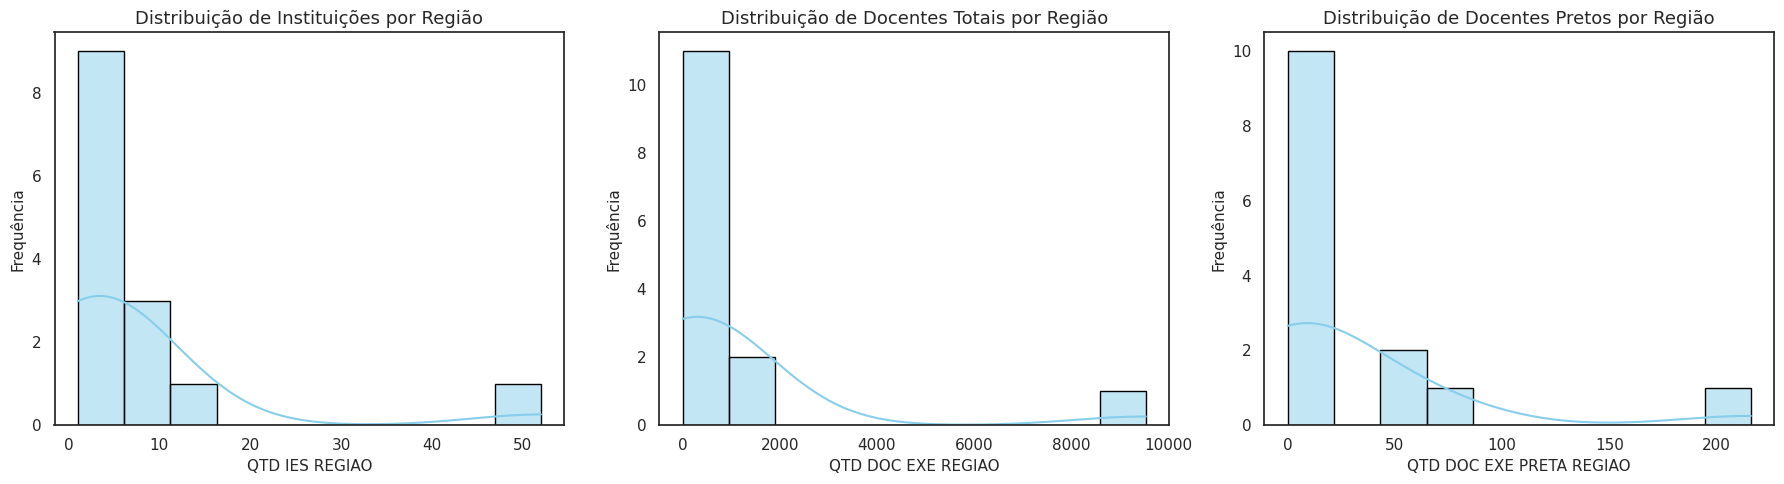

In [133]:
# Configurar estilo sem grid
sns.set_style("white")

# Lista de variáveis e títulos
variaveis = ['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']
titulos = [
    'Distribuição de Instituições por Região',
    'Distribuição de Docentes Totais por Região',
    'Distribuição de Docentes Pretos por Região'
]

# Criar subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(variaveis):
    sns.histplot(
        data=df_resultado_regiao,
        x=var,
        kde=True,
        ax=axes[i],
        color='skyblue',
        edgecolor='black',
        bins=10
    )
    axes[i].set_title(titulos[i], fontsize=13)
    axes[i].set_xlabel(var.replace('_', ' '), fontsize=11)
    axes[i].set_ylabel('Frequência', fontsize=11)
    axes[i].grid(False)

plt.tight_layout()
plt.show()



# Análise dos gráficos histograma


* QTD_IES_REGIAO (Instituições por Região)

  A distribuição é assimétrica à direita, com poucas regiões concentrando a maioria das IES. A maioria das regiões possui entre 1 e 7 instituições, com um pico extremo (outlier) próximo de 52.

* QTD_DOC_EXE_REGIAO (Docentes Totais por Região)

  A curva mostra uma grande assimetria, indicando que poucas regiões concentram a maior parte dos docentes. A maior parte das regiões possui menos de 500 docentes, enquanto uma delas ultrapassa os 9 mil.

* QTD_DOC_EXE_PRETA_REGIAO (Docentes Pretos por Região)

  A distribuição é bastante concentrada perto de zero, refletindo sub-representação em muitas regiões. Há poucos casos com quantidades elevadas, revelando desigualdade marcante na composição racial dos docentes.

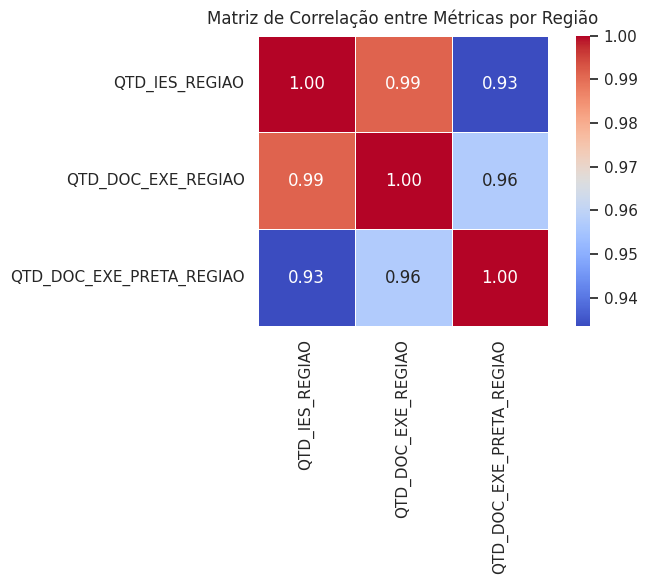

In [134]:
# Seleciona apenas as colunas numéricas desejadas
colunas = ["QTD_IES_REGIAO", "QTD_DOC_EXE_REGIAO", "QTD_DOC_EXE_PRETA_REGIAO"]
df_corr = df_resultado_regiao[colunas]

# Criação do gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

# Título e exibição
plt.title('Matriz de Correlação entre Métricas por Região', fontsize=12, pad=8)
plt.tight_layout()
plt.show()



##Análise do Gráfico


**A correlação entre QTD_DOC_EXE_REGIAO e QTD_DOC_EXE_PRETA_REGIAO é fortemente positiva** (valor próximo de 1), representada no gráfico por uma cor vermelha intensa, indicando que regiões com mais docentes em geral também concentram mais docentes pretos.

**A correlação entre QTD_IES_REGIAO e QTD_DOC_EXE_REGIAO é moderada e positiva**, vista por um tom laranja ou vermelho claro, sugerindo que mais instituições atraem mais docentes.

**Já a correlação entre QTD_IES_REGIAO e QTD_DOC_EXE_PRETA_REGIAO é mais fraca** (cor mais clara ou esbranquiçada), mostrando que o número de instituições não se relaciona fortemente com a presença de docentes pretos, apontando para uma possível desigualdade de distribuição.

Em resumo, apesar de regiões com mais docentes em geral também concentrarem mais docentes pretos, a presença de docentes pretos não cresce na mesma proporção que o número de instituições, o que indica que a distribuição racial entre docentes não acompanha o crescimento institucional — ou seja, não basta haver mais IES em uma região para que haja maior inclusão racial.

**Portanto, há sinais de desigualdade na distribuição de docentes pretos entre as regiões, sugerindo a necessidade de políticas específicas de equidade racial no corpo docente, além da simples expansão institucional.**



# ETAPA DE PRÉ-PROCESSAMENTO DE DADOS


## Análise exploratória-descritiva e não preditiva

Durante o processo de análise exploratória e descritiva, as principais hipóteses levantadas foram respondidas de forma satisfatória, sem a necessidade de modelagem preditiva. O dataset não apresenta uma variável-alvo com características adequadas para predição, e o foco da análise está na compreensão de padrões e relações existentes, o que se alinha com uma abordagem descritiva e diagnóstica, e não preditiva.

## Normalização

Com base na análise estatística e gráficos anteriores do dataframe df_resultado_regiao, percebemos que as escalas das variáveis são muito diferentes. A variável QTD_DOC_EXE_REGIAO, por exemplo, varia de 0 a 9539, enquanto QTD_IES_REGIAO varia apenas de 1 a 52. Isso pode distorcer análises comparativas, visuais ou estatísticas. Para poder comparar as variáveis de forma mais equilibrada, principalmente ao construir gráficos ou aplicar algoritmos de machine learning no futuro, os dados serão normalziados.




In [135]:
from sklearn.preprocessing import MinMaxScaler

# Copiar os dados originais
df_normalizado = df_resultado_regiao.copy()

# Selecionar as colunas a normalizar
colunas = ['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']

# Aplicar normalização Min-Max
scaler = MinMaxScaler()
df_normalizado[colunas] = scaler.fit_transform(df_normalizado[colunas])

# Exibir dados normalizados
print(df_normalizado)


                          Regiao  QTD_IES_REGIAO  QTD_DOC_EXE_REGIAO  QTD_DOC_EXE_PRETA_REGIAO
0                         Cariri        0.215686            0.171297                  0.254630
1                     Centro Sul        0.058824            0.024216                  0.046296
2               Grande Fortaleza        1.000000            1.000000                  1.000000
3                  Litoral Leste        0.000000            0.009435                  0.013889
4                  Litoral Norte        0.000000            0.001468                  0.004630
5   Litoral Oeste / Vale do Curu        0.000000            0.000000                  0.000000
6             Maciço de Baturité        0.019608            0.051473                  0.337963
7              Serra da Ibiapaba        0.117647            0.036796                  0.046296
8                 Sertão Central        0.117647            0.027571                  0.027778
9              Sertão de Canindé        0.019608  

##**Análise**: A normalização traz os dados para a mesma escala (entre 0 e 1), o que melhora a comparabilidade, evita viés em algoritmos e melhora a interpretação visual e estatística. Agora, vamos ver como ficará o histograma das variáveis normalizadas.

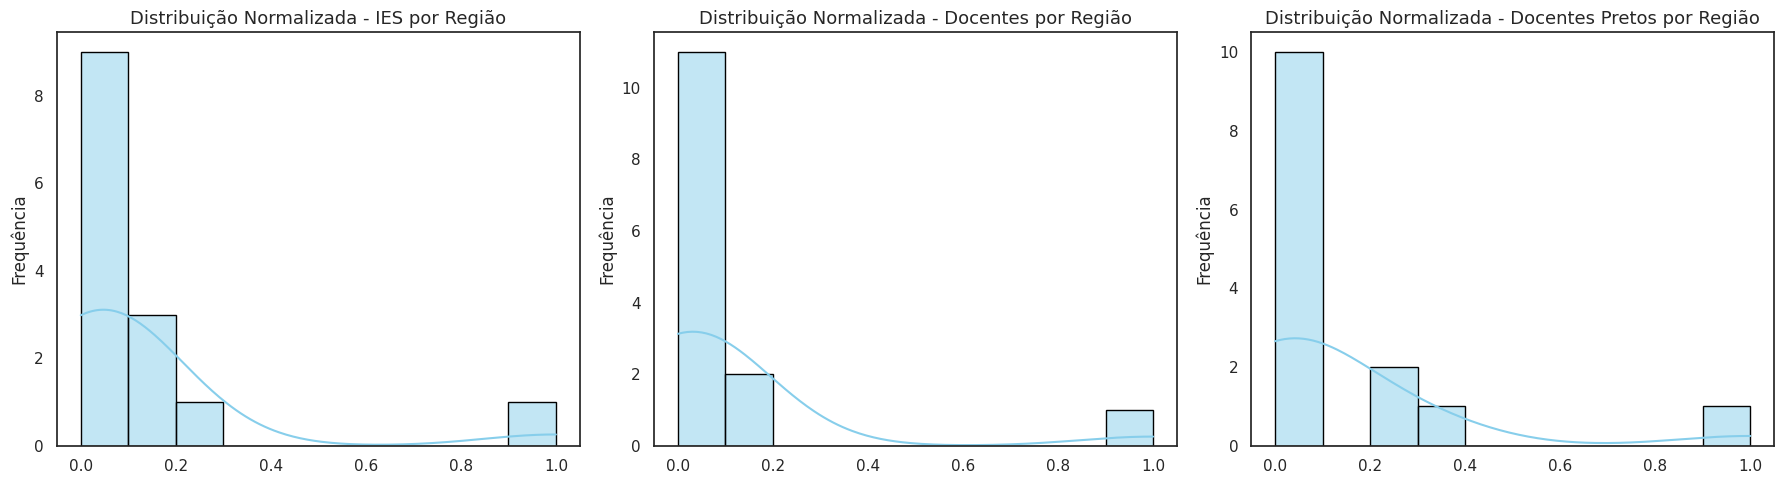

In [136]:
# =========================
# Normalizar os dados
# =========================

# Copiar DataFrame original
df_normalizado = df_resultado_regiao.copy()

# Colunas a normalizar
colunas = ['QTD_IES_REGIAO', 'QTD_DOC_EXE_REGIAO', 'QTD_DOC_EXE_PRETA_REGIAO']

# Aplicar Min-Max normalization
scaler = MinMaxScaler()
df_normalizado[colunas] = scaler.fit_transform(df_normalizado[colunas])

# =========================
# Visualização: Histogramas lado a lado
# =========================

# Estilo sem grid
sns.set_style("white")

# Criar os subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Títulos dos gráficos
titulos = [
    'Distribuição Normalizada - IES por Região',
    'Distribuição Normalizada - Docentes por Região',
    'Distribuição Normalizada - Docentes Pretos por Região'
]

# Plotar histogramas com curva de densidade
for i, col in enumerate(colunas):
    sns.histplot(
        data=df_normalizado,
        x=col,
        kde=True,
        bins=10,
        color='skyblue',
        edgecolor='black',
        ax=axes[i]
    )
    axes[i].set_title(titulos[i], fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')
    axes[i].grid(False)

plt.tight_layout()
plt.show()


## Análise dos gráficos normalizados:

Antes da normalização, as variáveis tinham escalas muito diferentes, variando de 1 a 9539, o que distorce comparações diretas. Após a normalização, todas as variáveis foram reescaladas para o intervalo entre 0 e 1, permitindo comparações justas e proporcionais.
<br>
<br>

QTD_IES_REGIAO (Instituições por Região)

A maior parte das regiões concentra-se na faixa mais baixa de instituições (próximo de 0 na escala normalizada), indicando alta concentração de IES em poucas regiões.A curva de densidade tem cauda longa à direita, revelando forte assimetria positiva e a presença de um ou poucos outliers com muitos polos de ensino.

<br>

QTD_DOC_EXE_REGIAO (Docentes por Região)
A distribuição é ainda mais concentrada perto do zero, mostrando que a maioria das regiões tem poucos docentes em relação ao total. A curva também apresenta assimetria acentuada, com um ou dois valores extremos puxando a média para cima (regiões com muitos docentes).

<br>

QTD_DOC_EXE_PRETA_REGIAO (Docentes Pretos por Região)
A densidade é fortemente concentrada no início da escala, indicando que em muitas regiões a presença de docentes pretos é extremamente baixa. O padrão reforça uma desigualdade racial significativa, com poucas regiões apresentando proporções mais elevadas, o que aparece como cauda longa à direita.

<br>

Resumo geral:
Os três histogramas revelam distribuições fortemente assimétricas, com a maioria das regiões acumulando valores baixos e poucas regiões concentrando os maiores valores. Isso indica desigualdade significativa na distribuição de instituições e docentes — especialmente em relação à presença de docentes pretos.







## Padronização


In [137]:
# Dados de entrada: df_resultado_regiao
colunas_numericas = ["QTD_IES_REGIAO", "QTD_DOC_EXE_REGIAO", "QTD_DOC_EXE_PRETA_REGIAO"]

# Instanciando o scaler
scaler = StandardScaler()

# Aplicando padronização
padronizados = scaler.fit_transform(df_resultado_regiao[colunas_numericas])

# Criando DataFrame com colunas padronizadas
df_padronizado = pd.DataFrame(padronizados, columns=[col + "_pad" for col in colunas_numericas])

# Juntando com as regiões para exibir
df_resultado_pad = pd.concat([df_resultado_regiao[["Regiao"]], df_padronizado], axis=1)

# Exibindo os dados padronizados (arredondados)
print(df_resultado_pad.round(2))


                          Regiao  QTD_IES_REGIAO_pad  QTD_DOC_EXE_REGIAO_pad  QTD_DOC_EXE_PRETA_REGIAO_pad
0                         Cariri                0.37                    0.26                          0.43
1                     Centro Sul               -0.25                   -0.32                         -0.37
2               Grande Fortaleza                3.49                    3.54                          3.29
3                  Litoral Leste               -0.48                   -0.38                         -0.50
4                  Litoral Norte               -0.48                   -0.41                         -0.53
5   Litoral Oeste / Vale do Curu               -0.48                   -0.41                         -0.55
6             Maciço de Baturité               -0.41                   -0.21                          0.75
7              Serra da Ibiapaba               -0.02                   -0.27                         -0.37
8                 Sertão Central     

**Análise:** Após a padronização, todas as variáveis passaram a ter média zero e desvio padrão um, permitindo comparações proporcionais entre regiões. Valores positivos indicam que a região está acima da média nacional naquela métrica, enquanto valores negativos mostram que está abaixo. Essa transformação facilita uma análise mais justa e clara das desigualdades relativas entre as regiões.

A seguir, veremos os histogramas padronizados.

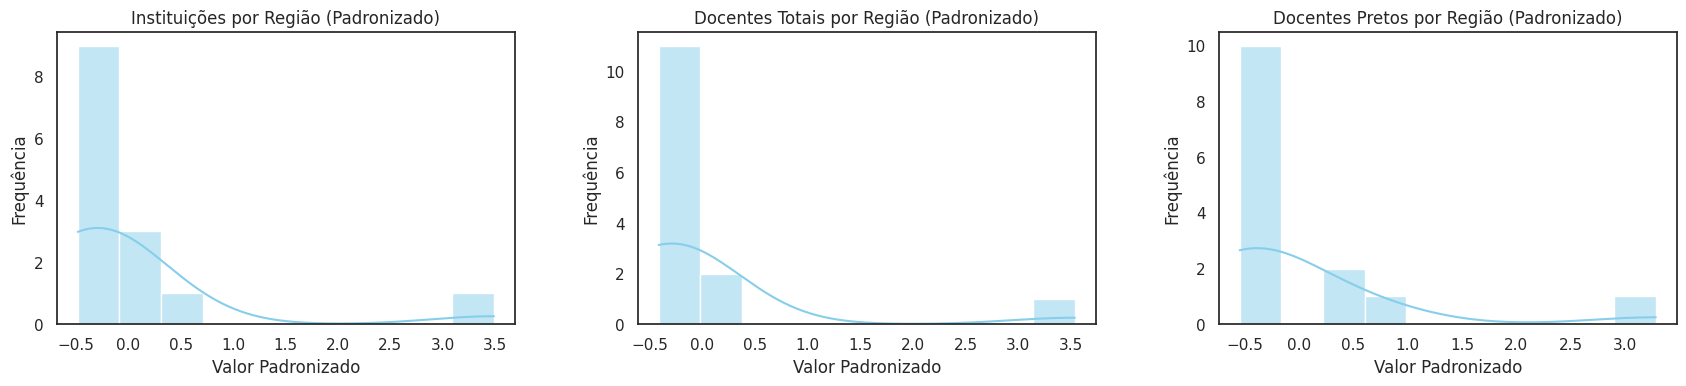

In [138]:
# Seleção das colunas numéricas
colunas_numericas = ["QTD_IES_REGIAO", "QTD_DOC_EXE_REGIAO", "QTD_DOC_EXE_PRETA_REGIAO"]

# Padronização
scaler = StandardScaler()
padronizados = scaler.fit_transform(df_resultado_regiao[colunas_numericas])
df_padronizado = pd.DataFrame(padronizados, columns=[col + "_pad" for col in colunas_numericas])

# Plotando os histogramas com curva de densidade
plt.figure(figsize=(18, 5))  # Aumenta a largura do gráfico

titulos = [
    "Instituições por Região (Padronizado)",
    "Docentes Totais por Região (Padronizado)",
    "Docentes Pretos por Região (Padronizado)"
]

for i, coluna in enumerate(df_padronizado.columns):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_padronizado[coluna], kde=True, bins=10, color='skyblue')
    plt.title(titulos[i], fontsize=12)
    plt.xlabel("Valor Padronizado")
    plt.ylabel("Frequência")

plt.tight_layout(pad=4.0)  # Aumenta o espaço entre os gráficos
plt.show()



##**Análise dos gráficos padronizados:**

Os três gráficos padronizados mostram distribuições assimétricas, especialmente para docentes pretos e docentes totais, com concentração de regiões abaixo da média. A curva de densidade reforça que poucos casos extremos puxam a média para cima. Isso indica forte desigualdade na distribuição de instituições e presença docente nas regiões analisadas.

#**Conclusão**

Conforme levantado inicialmente, o objetivo desta pesquisa era levantar o panorama de distribuição de instituições de ensino superior e de docentes declarados pretos no estado do Ceará por município e, posteriormente, por região, a fim de identificar distorções nessa distribuição de forma a justificar a criação de mais instituições por região de planejamento e de mais políticas públicas para incrementar o número de docentes declarados pretos nas regiões de maior carência.

Para tanto, os quantitativos em questão foram explorados, tratados e analisados e, com base na análise estatística e gráfica dos dados, **conclui-se que há uma desigualdade marcante na distribuição das instituições de ensino superior, de docentes e, principalmente, docentes pretos entre as regiões.** As distribuições assimétricas e os altos desvios padrão indicam forte concentração em poucas regiões, enquanto a maioria apresenta valores baixos ou nulos. **A correlação entre docentes totais e docentes pretos é alta, mas a correlação fraca entre número de instituições e presença de docentes pretos revela que o aumento institucional não garante diversidade racial.**

A análise também mostrou que a normalização foi essencial para revelar essas desigualdades de forma proporcional. Esses achados reforçam a necessidade de políticas públicas voltadas à equidade no acesso, permanência e representatividade no ensino superior.

**Por fim, os resultados revelaram que as regiões do estado com maior carência de instituições e de docentes pretos são Litoral Oeste / Vale do Curu, Sertão dos Inhamuns e Litoral Norte.** Essas regiões apresentaram valores muito abaixo da média e da mediana em todas as métricas, necessitando, portanto, de maiories iniciativas voltadas tanto à expansão de sedes de instituições de ensino superior (IES), quanto à promoção de diversidade racial no corpo docente (docentes declarados pretos).

















